# Caso de estudio DANE: Cuál es el comportamiento regional de las licencias de construcción  aprobadas (ELIC) en Colombia? Análisis ELIC Enero 2019 - Abril 2026

### *¿Cómo se distribuyen geográficamente las licencias de construcción aprobadas en los departamentos y municipios de Colombia, qué revela la relación VIS / No VIS sobre la oferta de vivienda social por región,y qué destinos de construcción predominan en cada zona del país?*



**Author:** Luis Alejandro Alarcón Vargas  
**Date:** Junio 2026  
**Tools:** Python, Pandas, SQL, Power BI.  
**Data source:** [DANE](https://www.dane.gov.co/files/operaciones/ELIC/anex-ELIC-SerieTipoBaseMun-abr2026.xlsx)

## Contexto del Negocio

ELIC (Estadística de Licencias de Construcción) es la operación estadística 
oficial que realiza mensualmente el DANE (Departamento Administrativo Nacional 
de Estadística) de Colombia. Mide el área y el número de unidades de vivienda 
aprobadas para construcción en los municipios colombianos, con base en las 
licencias de construcción expedidas por las curadurías urbanas y oficinas de 
planeación municipal.

Es importante precisar que ELIC mide únicamente **licencias aprobadas** — es 
decir, el permiso legal para construir — y no la construcción efectivamente 
ejecutada ni finalizada. Por lo tanto, esta estadística refleja solo una parte 
de la dinámica constructora real: la intención formal de construir, que 
antecede a la obra física y que puede o no materializarse en su totalidad.

Desde Enero de 2019, la cobertura municipal de ELIC recopiló datos de más de 
1,000 municipios — casi la totalidad del país — permitiendo, por primera vez, 
una visión geográfica casi completa de la actividad constructora colombiana 
a nivel municipal.

Entender cómo se distribuye esta actividad licenciada entre departamentos y 
municipios, cómo se compone entre vivienda VIS (vivienda de interés social) 
y No VIS (vivienda de mercado), y qué destinos de construcción predominan 
en cada región (vivienda, comercio, industria, etc.), es esencial para 
identificar dónde está creciendo —formalmente— la oferta constructora del 
país, y de qué tipo.

## Tarea de Negocio

Analizar la distribución geográfica de las licencias de construcción 
aprobadas en los municipios colombianos entre enero de 2019 y abril 
de 2026, con énfasis en la composición entre vivienda VIS y No VIS, y en 
los distintos destinos de construcción (vivienda, comercio, industria, 
entre otros), con el fin de identificar patrones regionales en la 
dinámica constructora licenciada del país.

## Pregunta Clave
*¿Cómo se distribuyen geográficamente las licencias de construcción 
aprobadas en los departamentos y municipios de Colombia, qué revela 
la relación VIS / No VIS sobre la oferta de vivienda social por región, 
y qué destinos de construcción predominan en cada zona del país?*

## Tabla de Contenidos

1. [Preguntar — Tarea de Negocio](#1-preguntar)
2. [Preparar — Fuentes de Datos](#2-preparar)
3. [Procesar — Limpieza de Datos](#3-procesar)
4. [Analizar — Análisis Exploratorio](#4-analizar)
5. [Compartir — Visualizaciones y Hallazgos](#5-compartir)
6. [Actuar — Recomendaciones](#6-actuar)

## 1. Preguntar — Tarea de negocio <a name="1-ask"></a>

## Declaración de la Tarea de Negocio

Analizar la distribución geográfica de las licencias de construcción aprobadas 
en los municipios colombianos entre enero de 2019 y abril de 2026, usando 
datos históricos de ELIC-DANE, con el fin de identificar patrones regionales en 
la composición VIS / No VIS y en los destinos de construcción, que sirvan como 
insumo para el análisis de la dinámica constructora licenciada del país.

### Stakeholders Clave

| Stakeholder | Rol | Interés en este análisis |
|---|---|---|
| Director de Construcción - DANE | Toma de decisiones estadísticas | Calidad y representatividad de la estadística ELIC |
| Encargado de Estudios Económicos del Sector Construcción | Analista económico | Insumos para diagnóstico del sector y política pública |
| Entidades territoriales y curadurías urbanas | Fuente primaria de datos | Interés en el comportamiento constructor de su región |

### Preguntas Guía

El análisis se enfocará en las siguientes preguntas:

1. **¿Cómo** se distribuye geográficamente la actividad constructora licenciada 
   en Colombia, por departamento y municipio?
2. **¿Qué** revela la relación VIS / No VIS sobre la oferta de vivienda social 
   en cada región?
3. **¿Cuáles** destinos de construcción predominan en cada zona del país 
   (vivienda, comercio, industria, entre otros)?

**Este notebook aborda las tres preguntas de forma integrada, ya que están 
directamente conectadas con la tarea de negocio asignada.**

---
## 2. Preparar — Fuentes de datos <a name="2-prepare"></a>

### Descripción de la Fuente de Datos

- **Fuente:** [ELIC - Licencias de Construcción](https://www.dane.gov.co/index.php/estadisticas-por-tema/construccion/licencias-de-construccion) 
  publicado por el DANE (Departamento Administrativo Nacional de Estadística)
- **Archivo:** Serie tipo base por municipio (`anex-ELIC-SerieTipoBaseMun`)
- **Formato:** Excel (.xlsx), con hojas de datos, diccionario de variables y 
  lista de municipios
- **Periodo cubierto:** Enero 2005 — Abril 2026 *(dataset completo)*; 
  Enero 2019 — Abril 2026 *(subconjunto con cobertura de 1,000+ municipios)*
- **Frecuencia de actualización:** Mensual

### Estructura de los Datos

El archivo contiene un registro por cada licencia de construcción aprobada, 
con las siguientes variables:

| Columna | Descripción |
|---|---|
| `fecha` / `año` / `mes` | Periodo de la licencia aprobada |
| `cod_depto` / `Departamento` | Código y nombre del departamento |
| `cod_muni` / `Municipio` | Código y nombre del municipio |
| `cod_dane` | Código DIVIPOLA completo (5 dígitos) — clave para geolocalización |
| `obj_tra` | Tipo de trámite: nuevo o modificación |
| `clase_suelo` | Clase de suelo: urbana, sub-urbana o rural |
| `modalidad` | Modalidad de construcción: nueva o ampliación |
| `destino` | Destino de la construcción: vivienda, comercio, industria, etc. |
| `tipo_vivi` | Tipo de vivienda: casas o apartamentos |
| `VIS_NVIS` | Clasificación: VIS, No VIS o VIP |
| `estrato` | Estrato socioeconómico asociado |
| `area` | Área aprobada en metros cuadrados (m²) |
| `unidades` | Número de unidades de vivienda aprobadas |
| `licencias` | Número de licencias |
| `cobertura` | Nivel de cobertura municipal vigente en ese registro |

### Privacidad y Limitaciones

- No se incluye información personal identificable (PII) de constructores 
  o solicitantes
- Los datos reflejan **licencias aprobadas**, no construcción efectivamente 
  ejecutada o finalizada

### Credibilidad de los Datos — Evaluación ROCCC

| Criterio | Evaluación |
|---|---|
| **Confiable (Reliable)** | Datos de primera fuente, recolectados directamente por el DANE a partir de los registros de curadurías urbanas y oficinas de planeación municipal |
| **Original** | Datos primarios sin agregación por terceros |
| **Comprehensiva (Comprehensive)** | Cubre más de 1,000 municipios — casi la totalidad del territorio colombiano — desde enero de 2019 |
| **Actual (Current)** | Incluye el dato más reciente disponible: abril de 2026 |
| **Citada (Cited)** | Publicada oficialmente por el DANE, entidad estadística del Estado colombiano |

In [2]:
import pandas as pd
import requests
from io import BytesIO

# ── Descargar el archivo directamente desde el DANE ───────────
# Verifica/actualiza esta URL en la página del DANE cada vez que
# quieras la versión más reciente: dane.gov.co > Construcción > ELIC
url = "https://www.dane.gov.co/files/operaciones/ELIC/anex-ELIC-SerieTipoBaseMun-abr2026.xlsx"

response = requests.get(url, timeout=30)
response.raise_for_status()  # lanza error si la descarga falla

file_bytes = BytesIO(response.content)

df = pd.read_excel(file_bytes, sheet_name="elic",
                    dtype={"cod_depto": str, "cod_muni": str, "cobertura": str})
file_bytes.seek(0)  # reiniciar el puntero para leer la segunda hoja del mismo archivo
municipios = pd.read_excel(file_bytes, sheet_name="lista municipios",
                            dtype={"cod_depto": str, "cod_muni": str})

print(f"Archivo descargado desde: {url}")
print(f"Filas cargadas: {df.shape[0]:,}")
print(f"Municipios catalogados: {municipios.shape[0]:,}")

Archivo descargado desde: https://www.dane.gov.co/files/operaciones/ELIC/anex-ELIC-SerieTipoBaseMun-abr2026.xlsx
Filas cargadas: 336,134
Municipios catalogados: 1,104


In [3]:
# ── Diagnóstico inicial de los datos crudos ───────────────────────

print("=== Tipos de dato ===")
print(df.dtypes)

=== Tipos de dato ===
año             int64
mes             int64
cod_depto      object
cod_muni       object
obj_tra         int64
clase_suelo     int64
modalidad       int64
destino         int64
tipo_vivi       int64
VIS_NVIS        int64
estrato         int64
area            int64
unidades        int64
licencias       int64
cobertura      object
dtype: object


El tipo de datos cod_Depto y cod_muni así como cobertura se sugieren dejar como objects o texto en este caso, ya que en un futuro al hacer joins con la lista de municipios esto nos permitirá no tener errores.

In [4]:
# --- Valores nulos por columna ---

print("\n=== Valores nulos por columna ===")
print(df.isnull().sum())



=== Valores nulos por columna ===
año            0
mes            0
cod_depto      0
cod_muni       0
obj_tra        0
clase_suelo    0
modalidad      0
destino        0
tipo_vivi      0
VIS_NVIS       0
estrato        0
area           0
unidades       0
licencias      0
cobertura      0
dtype: int64


In [5]:
# --- Diagnóstico de duplicados y valores únicos ---
print("\n=== Filas duplicadas ===")
print(f"Duplicados exactos: {df.duplicated().sum():,}")

print("\n=== Valores únicos en variables categóricas (sin decodificar aún) ===")
for col in ["obj_tra", "clase_suelo", "modalidad", "destino", "tipo_vivi", "VIS_NVIS", "estrato", "cobertura"]:
    print(f"{col}: {sorted(df[col].dropna().unique())}")

print("\n=== Estadísticas descriptivas de variables numéricas ===")
print(df[["area", "unidades", "licencias"]].describe())


=== Filas duplicadas ===
Duplicados exactos: 0

=== Valores únicos en variables categóricas (sin decodificar aún) ===
obj_tra: [np.int64(1), np.int64(2)]
clase_suelo: [np.int64(1), np.int64(2), np.int64(3)]
modalidad: [np.int64(1), np.int64(2)]
destino: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12)]
tipo_vivi: [np.int64(0), np.int64(1), np.int64(2)]
VIS_NVIS: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
estrato: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]
cobertura: ['1000+', '302', '77', '88']

=== Estadísticas descriptivas de variables numéricas ===
                area       unidades      licencias
count  336134.000000  336134.000000  336134.000000
mean     1418.742653      11.752367       2.275946
std      6353.313870      75.318331       3.700998
min         1.000000       0.000000       0.000000
25%       123.000

Cómo podemos observar no hay valores nulos en ninguna de las columnas, así como cero filas duplicadas.
Esto indica que los datos están completos y no hay registros repetidos, lo cual es un buen punto de
partida para el análisis posterior. Además , las variables categóricas presentan un conjunto definido y preciso
de valores únicos, lo que facilita su interpretación y análisis.

## 3. Procesar — Limpieza de datos <a name="3-process"></a>

### Estrategia de Limpieza

Con base en el análisis exploratorio realizado, se identificaron y abordaron 
los siguientes aspectos:

| Aspecto | Decisión | Justificación |
|---|---|---|
| Códigos categóricos sin decodificar | Decodificar usando diccionarios de la hoja `guía` | Todos los valores únicos encontrados coinciden exactamente con las claves documentadas por el DANE — sin riesgo de `NaN` al aplicar `.map()` |
| `cod_depto` y `cod_muni` como texto | Forzar `dtype=str` desde la carga | Necesario para conservar ceros a la izquierda (ej. `05` para Antioquia) y garantizar códigos DIVIPOLA válidos para geolocalización |
| Valores nulos | Ninguna acción necesaria | No se encontraron valores nulos en ninguna columna |
| Filas duplicadas | Ninguna acción necesaria | No se encontraron duplicados exactos |
| Cobertura municipal variable en el tiempo | Generar dos datasets: completo y filtrado | El dataset completo (`elic_clean.csv`) preserva la serie histórica 2005–2026; el dataset filtrado (`elic_clean_cobertura1000.csv`) conserva solo registros con cobertura de 1,000+ municipios (sept. 2022 en adelante), garantizando comparabilidad geográfica completa |
| Variable `area` sin decimales | Ninguna acción necesaria | Confirmado que la fuente original del DANE reporta el área en metros cuadrados como número entero — no es una pérdida de precisión introducida en el procesamiento |

**Nota:** El dataset completo permite análisis de tendencia histórica de largo 
plazo usando los 302 municipios con cobertura constante desde 2016, mientras 
que el dataset filtrado permite un mapa geográfico completo de Colombia, 
sacrificando profundidad temporal a cambio de representatividad municipal con 1.104 municipios.

In [6]:
# ── Diccionarios de decodificación (extraídos de la hoja 'guía') ─
dict_obj_tra = {1: "nuevo", 2: "modificación"}
dict_clase_suelo = {1: "urbana", 2: "sub-urbana", 3: "rural"}
dict_modalidad = {1: "nueva", 2: "ampliación"}
dict_destino = {
    1: "vivienda", 2: "industria", 3: "oficina", 4: "bodega",
    5: "comercio", 6: "alojamiento", 7: "educación", 8: "salud-asistencial",
    9: "administración pública", 10: "religioso", 11: "social-recreacional", 12: "otros"
}
dict_tipo_vivi = {0: "No aplica", 1: "casas", 2: "apartamentos"}
dict_vis_novis = {0: "No aplica", 1: "VIS (no incluye VIP)", 2: "No VIS", 3: "VIP"}
dict_estrato = {
    0: "No aplica", 1: "Bajo-bajo", 2: "Bajo", 3: "Medio-bajo",
    4: "Medio", 5: "Medio-alto", 6: "Alto"
}

# ── Aplicar decodificación ────────────────────────────────────
df["obj_tra"] = df["obj_tra"].map(dict_obj_tra)
df["clase_suelo"] = df["clase_suelo"].map(dict_clase_suelo)
df["modalidad"] = df["modalidad"].map(dict_modalidad)
df["destino"] = df["destino"].map(dict_destino)
df["tipo_vivi"] = df["tipo_vivi"].map(dict_tipo_vivi)
df["VIS_NVIS"] = df["VIS_NVIS"].map(dict_vis_novis)
df["estrato"] = df["estrato"].map(dict_estrato)

# ── Unir con nombres de municipio y departamento ─────────────
municipios_clean = municipios[["cod_depto", "cod_muni", "Departamento", "Municipio"]]
df = df.merge(municipios_clean, on=["cod_depto", "cod_muni"], how="left")

# ── Crear columna de fecha estándar ───────────────────────────
df["fecha"] = pd.to_datetime(
    df["año"].astype(str) + "-" + df["mes"].astype(str).str.zfill(2) + "-01"
)

# ── Restaurar ceros a la izquierda en códigos DIVIPOLA ────────
df["cod_depto"] = df["cod_depto"].astype(str).str.zfill(2)
df["cod_muni"] = df["cod_muni"].astype(str).str.zfill(3)
df["cod_dane"] = df["cod_depto"] + df["cod_muni"]
df["cobertura"] = df["cobertura"].astype(str)

# ── Reordenar columnas ────────────────────────────────────────
df = df[[
    "fecha", "año", "mes",
    "cod_depto", "Departamento", "cod_muni", "Municipio", "cod_dane",
    "obj_tra", "clase_suelo", "modalidad", "destino",
    "tipo_vivi", "VIS_NVIS", "estrato",
    "area", "unidades", "licencias", "cobertura"
]]

# ── Verificación de nulos tras el merge ───────────────────────
nulos_merge = df["Municipio"].isnull().sum()
print(f"\nFilas sin match de municipio tras el merge: {nulos_merge}")

# ── Exportar dataset completo (todas las coberturas) ────────
output_path_full = "elic_clean.csv"
df.to_csv(output_path_full, index=False, encoding="utf-8-sig")
print(f"\nArchivo completo exportado: {output_path_full}")
print(f"Filas: {df.shape[0]:,}")


Filas sin match de municipio tras el merge: 0

Archivo completo exportado: elic_clean.csv
Filas: 336,134


In [10]:
# ── Filtrar por fecha desde 2019, cobertura de más de 1000 municipios y exportar ──────────────────────────
df_1000 = df[df["fecha"] >= "2019-01-01"].copy()

output_path_1000 = "elic_clean_cobertura1000.csv"
df_1000.to_csv(output_path_1000, index=False, encoding="utf-8-sig")

print(f"Archivo filtrado exportado: {output_path_1000}")
print(f"Filas: {df_1000.shape[0]:,}")
print(f"Municipios únicos (por nombre): {df_1000['Municipio'].nunique()}")
print(f"Municipios únicos (por código DANE): {df_1000['cod_dane'].nunique()}")
print(f"Rango de fechas: {df_1000['fecha'].min()} a {df_1000['fecha'].max()}")

Archivo filtrado exportado: elic_clean_cobertura1000.csv
Filas: 172,301
Municipios únicos (por nombre): 998
Municipios únicos (por código DANE): 1078
Rango de fechas: 2019-01-01 00:00:00 a 2026-04-01 00:00:00


**Nota:** De los 1,104 municipios habilitados en la cobertura ampliada de ELIC a Abril de 2026, 
1,078 (97.64%) registraron al menos una licencia de construcción aprobada entre 
enero de 2019 y abril de 2026, identificados de forma única mediante su código 
DIVIPOLA (`cod_dane`). Es importante señalar que 63 nombres de municipio se 
repiten en distintos departamentos del país (ej. "Buenavista" existe en 4 
departamentos distintos), por lo cual el código DIVIPOLA es el identificador 
correcto para cualquier análisis geográfico, y no el nombre del municipio.

Los 24 municipios habilitados restantes (2.36%) no presentaron actividad 
constructora formal registrada durante todo el periodo. Este hallazgo permitirá
más adelante analizar el comportamiento de las licencias y su concentración
dentro del territorio.

In [ ]:
import psycopg2
from sqlalchemy import create_engine

# ── Conexión a PostgreSQL ─────────────────────────────────────────
usuario = "postgres"
contraseña = "9532881"
host = "localhost"
puerto = "5432"
base_datos = "dane_construccion"

engine = create_engine(f"postgresql://{usuario}:{contraseña}@{host}:{puerto}/{base_datos}")

# ── Cargar municipios (sin duplicados) ────────────────────────────
municipios_unicos = df_1000[["cod_dane", "cod_depto", "Departamento", "cod_muni", "Municipio"]].drop_duplicates()
municipios_unicos.columns = ["cod_dane", "cod_depto", "departamento", "cod_muni", "municipio"]

municipios_unicos.to_sql("municipios", engine, if_exists="append", index=False)
print(f"Municipios cargados: {len(municipios_unicos)}")

# ── Cargar licencias ───────────────────────────────────────────────
licencias_df = df_1000[[
    "fecha", "año", "mes", "cod_dane", "obj_tra", "clase_suelo",
    "modalidad", "destino", "tipo_vivi", "VIS_NVIS", "estrato",
    "area", "unidades", "licencias"
]].copy()

licencias_df.columns = [
    "fecha", "anio", "mes", "cod_dane", "obj_tra", "clase_suelo",
    "modalidad", "destino", "tipo_vivi", "vis_novis", "estrato",
    "area", "unidades", "licencias"
]

licencias_df.to_sql("licencias", engine, if_exists="append", index=False)
print(f"Registros de licencias cargados: {len(licencias_df)}")

Municipios cargados: 1078
Registros de licencias cargados: 172301


## 4. Analizar — Analisis Exploratorio <a name="4-analizar"></a>

### Consultas SQL en PostgreSQL

Las siguientes consultas fueron ejecutadas directamente en PostgreSQL 
(pgAdmin 4) sobre las tablas `municipios` y `licencias`, con el fin de 
construir los KPIs que alimentarán el dashboard de Power BI.

### KPIs construidos

**KPI 1 — Área total licenciada por departamento**
Agrega el área total en m², unidades y licencias aprobadas por departamento,
ordenado de mayor a menor actividad constructora.

**Hallazgo:** Antioquia, Bogotá D.C. y Cundinamarca concentran 
el mayor volumen de área licenciada.


**KPI 2 — Ranking de municipios con mayor área licenciada**
Identifica los municipios con mayor volumen de construcción licenciada 
en el periodo 2019–2026, usando `cod_dane` como identificador único.

**Hallazgo:** Bogotá D.C, Cali y Medellín concentran el mayor volumen
de área licenciada, siendo Bogotá la que mayor concentra volumen de area
licenciada con diferencia, casi 5 veces la cantidad de Cali y Medellín.


**KPI 3 — Distribución VIS / No VIS / VIP por departamento**
Compara la composición de la vivienda licenciada según su clasificación 
social (VIS, No VIS, VIP) en cada departamento, excluyendo registros 
no aplicables a vivienda.

**Hallazgo:** A nivel Nacional, predomina la construcción de vivienda No Vis
con mas de la mitad de participación, seguida de la VIS y con una
participación muy pequeña de la VIP.


**KPI 4 — Composición del área licenciada por destino**
Desglosa el total de área licenciada según el destino de la construcción 
(vivienda, comercio, industria, oficina, etc.), incluyendo el porcentaje 
que representa cada destino sobre el total nacional.

**Hallazgo:** El destino que predomina para construir en Colombia es el de la 
vivienda, con una muy significativa diferencia sobre el segundo tipo de
destino de construcción que es el comercio, cuya representación es mínima,
al igual que los demás destinos.


**KPI 5 — Destino predominante por departamento**
Identifica el tipo de construcción con mayor área licenciada en cada 
departamento, usando una función de (`OVER PARTITION BY`) 
para seleccionar el destino dominante de cada región.

**Hallazgo:** Al igual que en el conglomerado nacional, en todos los departamentos
de Colombia, la vivienda es el destino predominante, no se halló un caso atipico
donde predomine otro destino. 


**KPI 6 — Casas vs Apartamentos por departamento**
Compara el volumen de área licenciada y unidades aprobadas entre casas 
y apartamentos en cada departamento, revelando patrones de preferencia 
constructiva regional.

**Hallazgo:** A primera vista, existen diferencias entre departamentos que se 
evidenciaran mejor en el analisis gráfico del siguiente apartado.

### Herramientas utilizadas
- **Motor:** PostgreSQL 
- **Cliente:** pgAdmin 4
- **Modelo relacional:** tabla `municipios` (dimensión) + tabla `licencias` 
  (hechos), vinculadas por `cod_dane` (código DIVIPOLA)
- **Funciones SQL avanzadas utilizadas:** `JOIN`, `GROUP BY`, `SUM`, 
  `ROUND`, `OVER (PARTITION BY...)`
- **Output:** 6 Querys listas desde pgAdmin, listos para su carga en Power BI.

## 5. Compartir  — Exponer Hallazgos <a name="4-analizar"></a>

Este Apartado analiza las licencias de construcción aprobadas en Colombia (fuente: ELIC - DANE), consolidando métricas clave de área licenciada en metros cuadrados, distribución territorial y destino socioeconómico del suelo para el período de análisis.

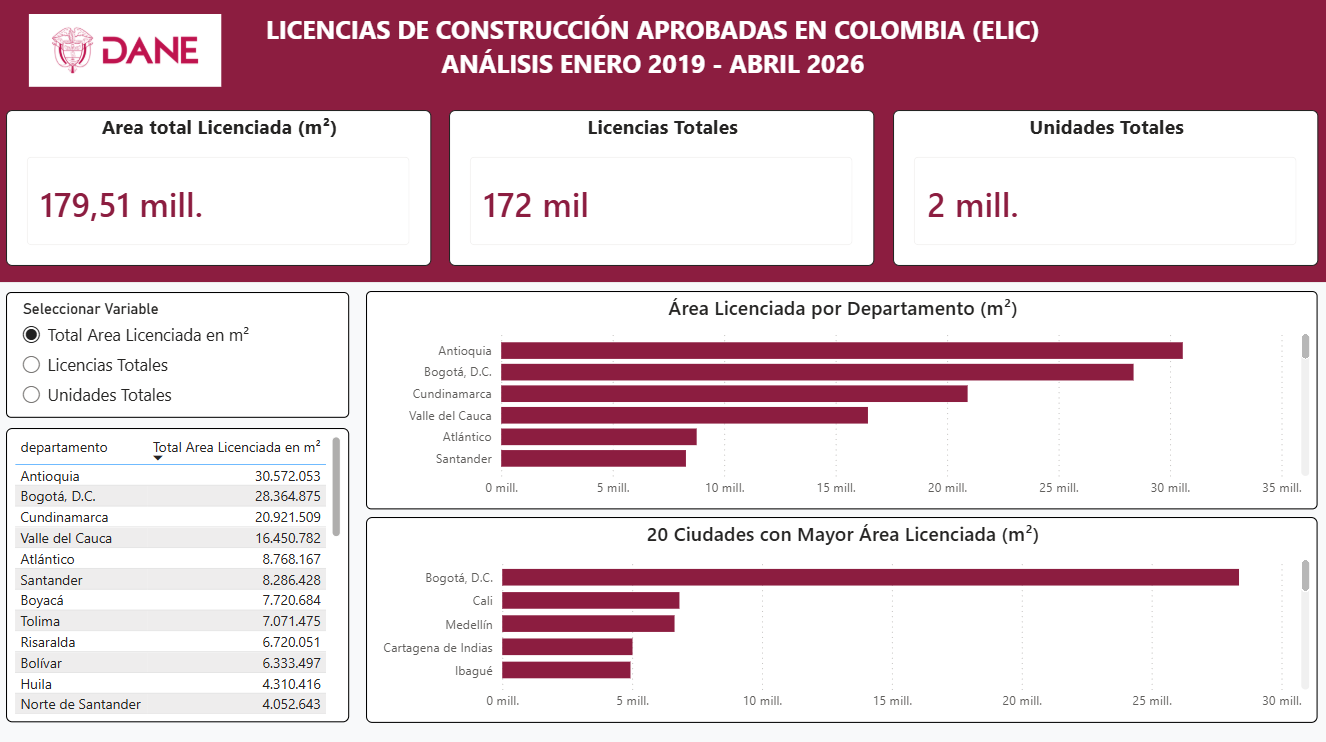

### Hallazgos
- **Bogotá concentra grandes cantidades de área licenciada**: Bogotá D.C. que también es clasificada como departamento por el DANE, ocupa el segundo lugar en area licenciada por departamentos, destacando su alto grado de representación, superando a departamentos principales como el Valle del cauca y el Atlantico. A nivel de ciudades es la primera con un amplio margen de ventaja: su área licenciada aprobada representa más de 4 veces el área de la segunda y tercera ciudad que son Cali y Medellin respectivamente, evidencianodo un alto grado de concentración en la capital a comparación de otras ciudades principales.

- **4 Departamentos representan más del 50% de licencias aprobadas a nivel nacional**: Antioquia, Bogotá D.C., Cundinamarca y Valle del Cauca son los 4 departamentos con mayores licencias de construcción aprobadas respectivamente, y juntos representan más del 50% de licencias de construcción aprobadas en Colombia durante el periodo estimado de Enero 2019 - Abril 2026, resaltando la importancia de estas regiones para el desarrollo del sector de la construcción del país.


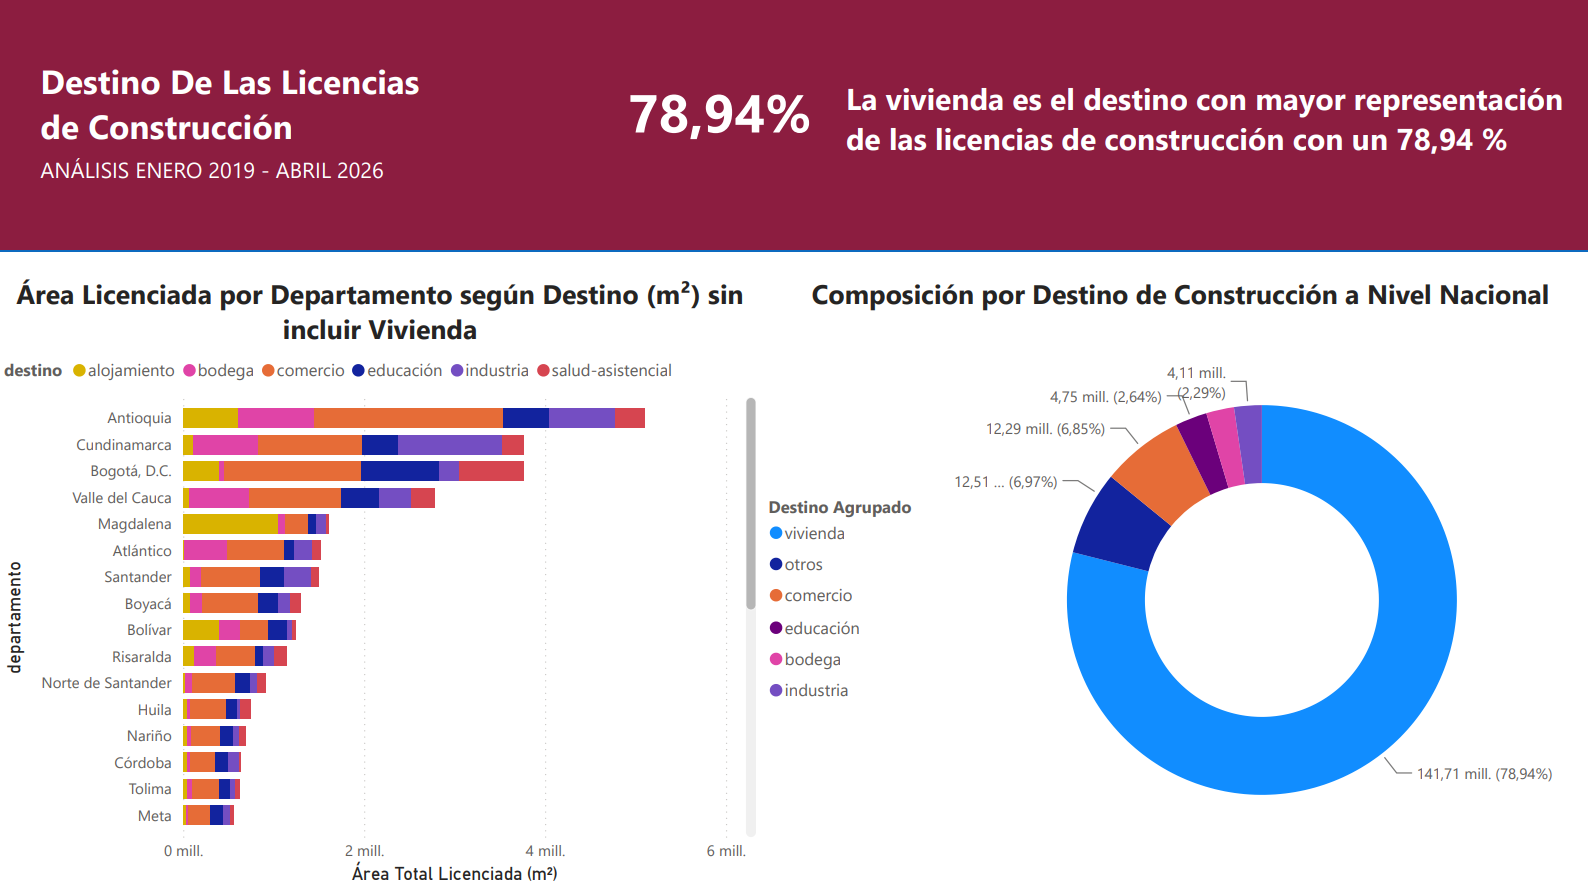

### Hallazgos
- **A nivel Nacional la vivienda es el destino dominante en lo que respecta a licencias aprobadas**: En Colombia para el periodo considerado la vivienda representa el 78,94% de licencias aprobadas según el destino de construcción, seguido del comercio, la educación, la bodega y la industria respectivamente, esto entre los más representativos después de la vivienda.

- **Excluyendo la vivienda, cada departamento muestra una historia diferente en lo que respecta a sus destinos preferidos en cuanto a licencias aprobadas**: Omitiendo la vivienda, se encuentra que existe ya un patrón particular para cada departamento en lo que respecta a destinos, aunque varios parecieran destinar más hacia el sector comercio, el caso de Magdalena es interesante, las licencias destinadas a alojamiento lideran la clasificación en este departamento, además esta el caso de Cundinamarca, donde la industria esta a la par del comercio como destinos de construcción. En resumen cada departamento cuenta historias diferentes, y para ello será importante analizar uno a uno para hallar más patrones y estadísticas.

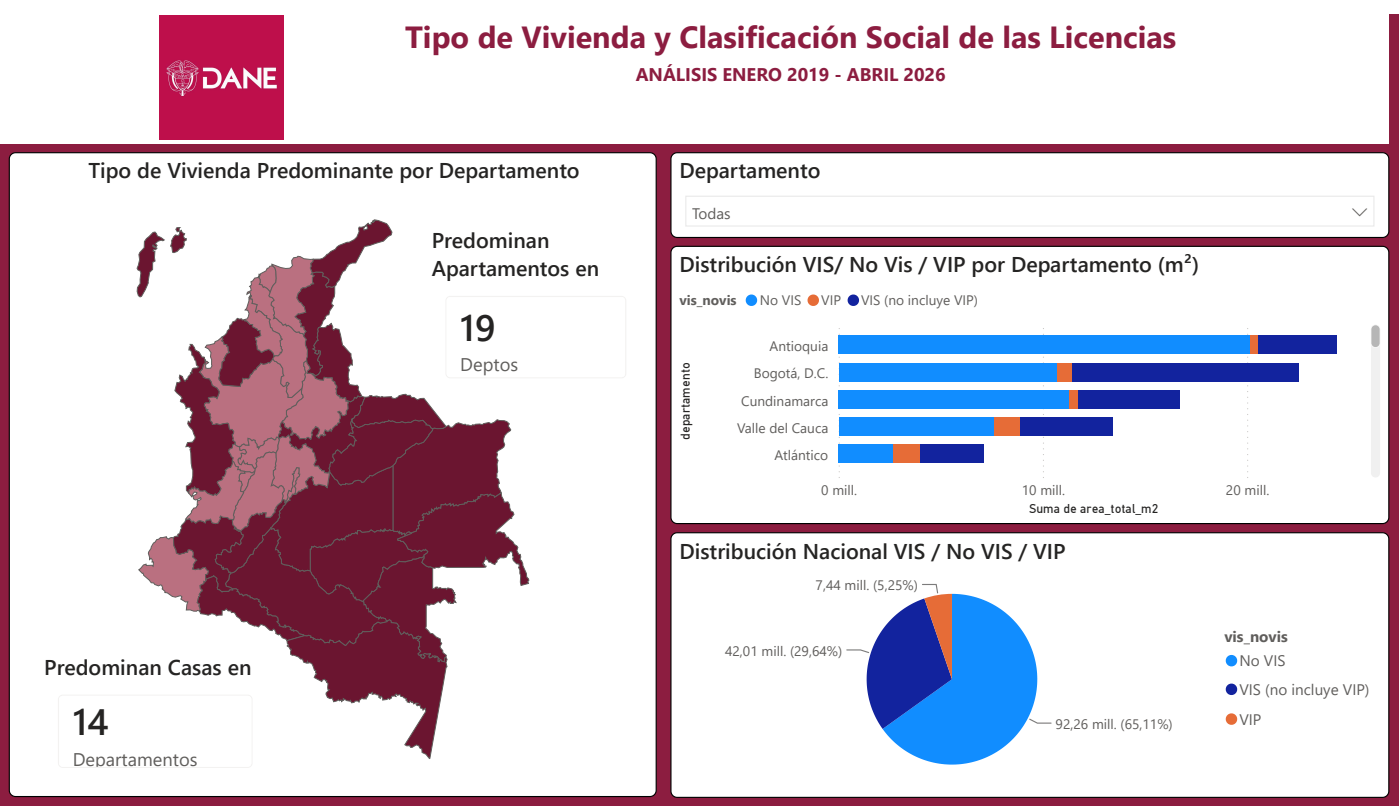

### Hallazgos
- **A nivel nacional los Apartamentos ya predominan como el tipo de vivienda con mayores licencias aprobadas frente a las casas**: En colombia 19 de los 33 departamentos analizados (Bogotá se incluye) en el periodo estimado licitaron más construcciones para la elaboración de departamentos, mientras que en los 14 restantes predominan las casas. A nivel geográfico, se puede evidenciar que en departamentos cuya extensión territorial es superior existe una mayor tendencia a la licitación de casas, mientras que en departamentos con menor extensión territorial tiende a observarse una mayor concentración de licencias para la construcción de Apartamentos. 

- **Las licencias de viviendas VIS y VIP representan el 34.89% de las licencias destinadas a vivienda**: En el análisis nacional durante el periodo estimado las viviendas No VIS, representaron el 65.11% del total nacional, mostrando una mayor representación de estas a Nivel Nacional, no obstante, el rubro de viviendas de interés social y prioritario hoy ya representan el 34.89% durante los ultimos 7 años que se están estimando, dentro de este análisis cabe reconocer que las VIP solo representan el 5,25% a nivel nacional, aún existen departamentos de Colombia que no registran este tipo de construcción.  

- **La clasificación social de viviendas varía en los 5 principales Departamentos**: Antioquia, Bogotá D.C, Cundinamarca, Valle del Cauca y Atlántico presentan los mayor cantidad de área aprobada en lo que respecta a vivienda, sin embargo, existe un factor importante a observar y es que tanto en Antioquia como Cundinarca el dominio de las viviendas No Vis es notable, representando más de un 60% del total; mientras que en Bogotá y Valle del Cauca, el comportamiento muestra una tendencia más equilibrada entre viviendas de caracter VIS y VIP, representando estas más del 50% en Bogotá y un poco más del 40% en Valle del Cauca. El valor que muestra el Atlantico es de resaltar, ya que a diferencia de los demás demás departamentos principales, este muestra una alta participación de los segmentos VIS Y VIP, representando casi 2/3 parte del total del departamento.  


## 6. Actuar  — Recomendaciones finales <a name="4-analizar"></a>

**Apertura de Datos y Portales de Analítica Territorial**:

 Promover tableros de control interactivos de acceso público (a partir de la microdata oficial) para que los pequeños municipios puedan consultar la vocación de su suelo y tomar decisiones de fiscalización tributaria (pago de delineación urbana e impuesto predial) sin depender de procesamientos complejos.

**Alineación con Planes de Ordenamiento Territorial (POT)** 

Dados los diferentes destinos no residenciales que predominan en cada departamento, es importante identificar los municipios que coinciden con un destino emergente predominante (ej. comercio o educación), estos deberían actualizar sus normativas de uso del suelo para ofrecer beneficios tributarios (como exenciones de predial o ICA) a las empresas que desarrollen proyectos afines a esa vocación.

**Promoción de Polos Descentralizados**

 El Gobierno Nacional y el Ministerio de Vivienda deben diseñar estímulos fiscales y normativos para atraer inversión privada hacia departamentos fuera del "Top 4", evitando la sobrepresión sobre la infraestructura vial y de servicios públicos de las principales áreas metropolitanas del país.

**Sistema de Alerta Temprana y Seguimiento a la Oferta VIP (5,25% Nacional)**

Sería optimo implementar un indicador de alerta estadística de oferta habitacional prioritaria, que identifique y visibilice en los boletines trimestrales a aquellos departamentos y municipios que registran 0% de área licenciada para VIP. Este reporte situacional servirá como insumo directo para que el Ministerio de Vivienda, Ciudad y Territorio (MVCT) y las alcaldías locales reorienten incentivos, gestionen la habilitación de suelo servido y focalicen los subsidios gubernamentales (Mi Casa Ya) en las zonas con rezago estructural de vivienda para la población de menores ingresos.